In [1]:
from qiskit.circuit import Parameter, QuantumCircuit, QuantumRegister, ClassicalRegister

from qiskit.quantum_info import Pauli, SparsePauliOp, Statevector, Operator
from scipy.optimize import minimize 
from qiskit.circuit.library import QFT
from qiskit import transpile
from qiskit.circuit.library import UnitaryGate

import random
import matplotlib.pyplot as plt
import scipy.linalg as scl
import numpy as np
from qiskit_aer import AerSimulator
from qiskit_ibm_runtime.fake_provider import FakeKyiv
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

backend = AerSimulator()

# sampler = Sampler(backend = backend)
pm = generate_preset_pass_manager(backend=backend,optimization_level=2)

In [2]:
nb_qubits = 8

N = 2**nb_qubits
m = np.zeros((N,N))
for j in range(N):
    if j == N-1:
        break
    else:
       m[j,j+1] = -1 

for j in range(N):
    if j == N-1:
        break
    else:
       m[j+1,j] = -1 
for j in range(N):
   m[j,j] = 2 
m[0] = np.array([1]+ [0]*(N-1))
m[1,0] = 0



In [4]:
# print(np.linalg.norm(b))
c = 1e-0
v0 = 1
y = 1
b = np.array([0,c,0,0,0,0,0,0,0,0,0,0,0,0,0,c+v0*y]*16)
b=b/np.linalg.norm(b)
# b
# print(np.linalg.det(m))

In [5]:
def U_b(nb_qubits):
    circ = QuantumCircuit(nb_qubits)
    circ.prepare_state(b)
    return circ
U = U_b(nb_qubits)
b = np.array(Statevector(U_b(nb_qubits)))
b

array([-2.42861287e-17+1.04083409e-17j,  1.11803399e-01-1.11022302e-16j,
        6.93889390e-18+2.08166817e-17j, -6.16297582e-33-1.54074396e-33j,
       -6.93889390e-18+1.73472348e-17j,  2.69630192e-33-2.69630192e-33j,
       -9.24446373e-33+1.92592994e-33j,  8.55284707e-49-3.25008189e-48j,
       -2.77555756e-17+3.46944695e-17j,  5.77778983e-33-1.42518816e-32j,
        1.54074396e-32+7.70371978e-33j, -1.36845553e-48-2.73691106e-48j,
       -6.93889390e-18+1.38777878e-17j, -4.62223187e-33-3.08148791e-33j,
       -4.85722573e-17+1.38777878e-17j,  2.23606798e-01+5.55111512e-17j,
       -2.42861287e-17+1.04083409e-17j,  1.11803399e-01-1.11022302e-16j,
        6.93889390e-18+2.08166817e-17j, -6.16297582e-33-1.54074396e-33j,
       -6.93889390e-18+1.73472348e-17j,  2.69630192e-33-2.69630192e-33j,
       -9.24446373e-33+1.92592994e-33j,  8.55284707e-49-3.25008189e-48j,
       -2.77555756e-17+3.46944695e-17j,  5.77778983e-33-1.42518816e-32j,
        1.54074396e-32+7.70371978e-33j, -1.36845553

In [6]:
def tensor(i,j,k,l,p,q,r,s):
        return np.kron(i,np.kron(j,np.kron(k,np.kron(l,np.kron(p,np.kron(q,np.kron(r,s)))))))
def Local_Hamiltonian(m):
    Ub = np.array(Operator(U_b(nb_qubits)))
    z = np.array([[1,0],
                 [0,-1]])
    I = np.array([[1,0],
                 [0,1]])
    M1 = (Ub@tensor(z,I,I,I,I,I,I,I)@np.conj(Ub.T)
        + Ub@tensor(I,z,I,I,I,I,I,I)@np.conj(Ub.T)
        + Ub@tensor(I,I,z,I,I,I,I,I)@np.conj(Ub.T)
        + Ub@tensor(I,I,I,z,I,I,I,I)@np.conj(Ub.T)
        + Ub@tensor(I,I,I,I,z,I,I,I)@np.conj(Ub.T)
        + Ub@tensor(I,I,I,I,I,z,I,I)@np.conj(Ub.T)
        + Ub@tensor(I,I,I,I,I,I,z,I)@np.conj(Ub.T)
        + Ub@tensor(I,I,I,I,I,I,I,z)@np.conj(Ub.T))

    M = 0.5*m.T@(tensor(I,I,I,I,I,I,I,I) - M1/nb_qubits)@m
    return M

A = Local_Hamiltonian(m)
d,u = np.linalg.eig(A)
sorted(d)

[(2.2183645565141808e-16-3.236470088630524e-17j),
 (1.227673800751643e-07-7.589421596682256e-17j),
 (7.603647244218035e-07-4.219995595899796e-17j),
 (1.964893707196407e-06-4.467172890525685e-17j),
 (6.557699033634183e-06+1.9794574508693878e-16j),
 (1.6391266484497608e-05+1.243762752553115e-16j),
 (2.478275038065926e-05-1.2539748686429098e-16j),
 (3.1515515432012276e-05-1.3050601596569216e-17j),
 (6.92511081485265e-05+3.416464764290586e-18j),
 (0.00013248011883615858-1.1694858291757474e-16j),
 (0.00018384085158191772-6.83584232227427e-17j),
 (0.00024156612989837892+1.7453294839369516e-16j),
 (0.00032781814852712773-6.345889824431775e-17j),
 (0.0004519655551216808+1.1034102068127947e-16j),
 (0.00046256729253985903-5.1553588710209876e-17j),
 (0.0005686531346856196-9.287765245074196e-17j),
 (0.0008377404763270451+9.797510656930289e-17j),
 (0.0012986958958941888-9.569081561629526e-17j),
 (0.0015635270368360094-1.2126543447381844e-16j),
 (0.0018282937125827404-1.0033592668799026e-16j),
 (0.0

In [7]:
U1=scl.expm(2**0*2*np.pi*1j*A) 
U2=scl.expm(2**1*2*np.pi*1j*A) 
U3=scl.expm(2**2*2*np.pi*1j*A) 
U4=scl.expm(2**3*2*np.pi*1j*A) 
U5=scl.expm(2**4*2*np.pi*1j*A) 
U6=scl.expm(2**5*2*np.pi*1j*A) 
U7=scl.expm(2**6*2*np.pi*1j*A) 
U8=scl.expm(2**7*2*np.pi*1j*A)
U9=scl.expm(2**8*2*np.pi*1j*A) 
U10=scl.expm(2**9*2*np.pi*1j*A) 
U11=scl.expm(2**10*2*np.pi*1j*A) 
U12=scl.expm(2**11*2*np.pi*1j*A)
U13=scl.expm(2**12*2*np.pi*1j*A) 
U14=scl.expm(2**13*2*np.pi*1j*A) 
U15=scl.expm(2**14*2*np.pi*1j*A)
U16=scl.expm(2**15*2*np.pi*1j*A) 
U17=scl.expm(2**16*2*np.pi*1j*A) 
U18=scl.expm(2**17*2*np.pi*1j*A) 

 
u1gate=UnitaryGate(U1)
u2gate=UnitaryGate(U2)
u3gate=UnitaryGate(U3)
u4gate=UnitaryGate(U4)
u5gate=UnitaryGate(U5)
u6gate=UnitaryGate(U6)
u7gate=UnitaryGate(U7)
u8gate=UnitaryGate(U8)
u9gate=UnitaryGate(U9)
u10gate=UnitaryGate(U10)
u11gate=UnitaryGate(U11)
u12gate=UnitaryGate(U12)
u13gate=UnitaryGate(U13)
u14gate=UnitaryGate(U14)
u15gate=UnitaryGate(U15)
u16gate=UnitaryGate(U16)
u17gate=UnitaryGate(U17)
u18gate=UnitaryGate(U18)



In [8]:
Id = np.identity(2**nb_qubits)
z0 = np.array([[1,0],
               [0,0]])
z1 = np.array([[0,0],
               [0,1]])

CU1 = np.kron(Id,z0) + np.kron(U1,z1)
CU2 = np.kron(Id,z0) + np.kron(U2,z1)
CU3 = np.kron(Id,z0) + np.kron(U3,z1)
CU4 = np.kron(Id,z0) + np.kron(U4,z1)
CU5 = np.kron(Id,z0) + np.kron(U5,z1)
CU6 = np.kron(Id,z0) + np.kron(U6,z1)
CU7 = np.kron(Id,z0) + np.kron(U7,z1)
CU8 = np.kron(Id,z0) + np.kron(U8,z1)
CU9 = np.kron(Id,z0) + np.kron(U9,z1)
CU10 = np.kron(Id,z0) + np.kron(U10,z1)
CU11 = np.kron(Id,z0) + np.kron(U11,z1)
CU12 = np.kron(Id,z0) + np.kron(U12,z1)
CU13 = np.kron(Id,z0) + np.kron(U13,z1)
CU14 = np.kron(Id,z0) + np.kron(U14,z1)
CU15 = np.kron(Id,z0) + np.kron(U15,z1)
CU16 = np.kron(Id,z0) + np.kron(U16,z1)
CU17 = np.kron(Id,z0) + np.kron(U17,z1)
CU18 = np.kron(Id,z0) + np.kron(U18,z1)



C_u1gate=UnitaryGate(CU1)
C_u2gate=UnitaryGate(CU2)
C_u3gate=UnitaryGate(CU3)
C_u4gate=UnitaryGate(CU4)
C_u5gate=UnitaryGate(CU5)
C_u6gate=UnitaryGate(CU6)
C_u7gate=UnitaryGate(CU7)
C_u8gate=UnitaryGate(CU8)
C_u9gate=UnitaryGate(CU9)
C_u10gate=UnitaryGate(CU10)
C_u11gate=UnitaryGate(CU11)
C_u12gate=UnitaryGate(CU12)
C_u13gate=UnitaryGate(CU13)
C_u14gate=UnitaryGate(CU14)
C_u15gate=UnitaryGate(CU15)
C_u16gate=UnitaryGate(CU16)
C_u17gate=UnitaryGate(CU17)
C_u18gate=UnitaryGate(CU18)



In [9]:
output1 = np.array(Operator(C_u1gate))
output2 = np.array(Operator(C_u2gate))
output3 = np.array(Operator(C_u3gate))
output4 = np.array(Operator(C_u4gate))
output5 = np.array(Operator(C_u5gate))
output6 = np.array(Operator(C_u6gate))
output7 = np.array(Operator(C_u7gate))
output8 = np.array(Operator(C_u8gate))
output9 = np.array(Operator(C_u9gate))
output10 = np.array(Operator(C_u10gate))
output11 = np.array(Operator(C_u11gate))
output12 = np.array(Operator(C_u12gate))
output13 = np.array(Operator(C_u13gate))
output14 = np.array(Operator(C_u14gate))
output15 = np.array(Operator(C_u15gate))
output16 = np.array(Operator(C_u16gate))
output17 = np.array(Operator(C_u17gate))
output18 = np.array(Operator(C_u18gate))

np.save("cu1.npy", output1)
np.save("cu2.npy", output2)
np.save("cu3.npy", output3)
np.save("cu4.npy", output4)
np.save("cu5.npy", output5)
np.save("cu6.npy", output6)
np.save("cu7.npy", output7)
np.save("cu8.npy", output8)
np.save("cu9.npy", output9)
np.save("cu10.npy", output10)
np.save("cu11.npy", output11)
np.save("cu12.npy", output12)
np.save("cu13.npy", output13)
np.save("cu14.npy", output14)
np.save("cu15.npy", output15)
np.save("cu16.npy", output16)
np.save("cu17.npy", output17)
np.save("cu18.npy", output18)

In [10]:
cu1 = np.load("cu1.npy")
cu2 = np.load("cu2.npy")
cu3 = np.load("cu3.npy")
cu4 = np.load("cu4.npy")
cu5 = np.load("cu5.npy")
cu6 = np.load("cu6.npy")
cu7 = np.load("cu7.npy")
cu8 = np.load("cu8.npy")
cu9 = np.load("cu9.npy")
cu10 = np.load("cu10.npy")
cu11 = np.load("cu11.npy")
cu12 = np.load("cu12.npy")
cu13 = np.load("cu13.npy")
cu14 = np.load("cu14.npy")
cu15 = np.load("cu15.npy")
cu16 = np.load("cu16.npy")
cu17 = np.load("cu17.npy")
cu18 = np.load("cu18.npy")


C_u1 = Operator(cu1).to_instruction()
C_u2 = Operator(cu2).to_instruction()
C_u3 = Operator(cu3).to_instruction()
C_u4 = Operator(cu4).to_instruction()
C_u5 = Operator(cu5).to_instruction()
C_u6 = Operator(cu6).to_instruction()
C_u7 = Operator(cu7).to_instruction()
C_u8 = Operator(cu8).to_instruction()
C_u9 = Operator(cu9).to_instruction()
C_u10 = Operator(cu10).to_instruction()
C_u11 = Operator(cu11).to_instruction()
C_u12 = Operator(cu12).to_instruction()
C_u13 = Operator(cu13).to_instruction()
C_u14 = Operator(cu14).to_instruction()
C_u15 = Operator(cu15).to_instruction()
C_u16 = Operator(cu16).to_instruction()
C_u17 = Operator(cu17).to_instruction()
C_u18 = Operator(cu18).to_instruction()

In [11]:
def ansatz(Parameters):
    qc = QuantumCircuit(N)
    for d in range(depth):
        param1=Parameters[d*9*N:(d+1)*(9*N)]
        for q in range(N):
            qc.ry(param1[q],qubits[q])
            qc.ry(param1[q+N],qubits[q])
            qc.ry(param1[q+2*N],qubits[q])
        qc.barrier()
        for q in range(N):
            qc.cx(qubits[q], qubits[(q+1)% N])
            qc.ry(param1[q+3*N],qubits[q])
            qc.ry(param1[q+4*N],qubits[(q+1)% N])
            qc.cx(qubits[(q+1)% N], qubits[q])
            qc.ry(param1[q+5*N],qubits[(q+1)% N])
            qc.cx(qubits[q], qubits[(q+1)% N])
        qc.barrier()
        if d==depth-1:
            for q in range(N):
                qc.ry(param1[q+6*N],qubits[q])
                qc.ry(param1[q+7*N],qubits[q])
                qc.ry(param1[q+8*N],qubits[q])
        qc.barrier()
    
    return qc


depth = 3
qubits=list(range(nb_qubits))
N=len(qubits)
nb_params=int(9*N*depth)
parameters = np.array([random.random() for _ in range(0, nb_params)])

# ansatz(Parameters).draw("mpl")

In [12]:
def circ(parameters):
    x=QuantumRegister(26)
    c=ClassicalRegister(18)
    circuit = QuantumCircuit(x,c)
    phi=parameters
    circuit=circuit.compose(ansatz(parameters),x[18:26])
    circuit.h(x[0:18])

#Apply the C-U operations where the controlled qubits are the qubits of the register x and the target from y    
    circuit.append(C_u1, [x[0],x[18],x[19],x[20],x[21],x[22],x[23],x[24],x[25]])    
    circuit.append(C_u2, [x[1],x[18],x[19],x[20],x[21],x[22],x[23],x[24],x[25]])    
    circuit.append(C_u3, [x[2],x[18],x[19],x[20],x[21],x[22],x[23],x[24],x[25]])    
    circuit.append(C_u4, [x[3],x[18],x[19],x[20],x[21],x[22],x[23],x[24],x[25]])  
    circuit.append(C_u5, [x[4],x[18],x[19],x[20],x[21],x[22],x[23],x[24],x[25]])    
    circuit.append(C_u6, [x[5],x[18],x[19],x[20],x[21],x[22],x[23],x[24],x[25]])    
    circuit.append(C_u7, [x[6],x[18],x[19],x[20],x[21],x[22],x[23],x[24],x[25]])    
    circuit.append(C_u8, [x[7],x[18],x[19],x[20],x[21],x[22],x[23],x[24],x[25]]) 
    circuit.append(C_u9, [x[8],x[18],x[19],x[20],x[21],x[22],x[23],x[24],x[25]])    
    circuit.append(C_u10, [x[9],x[18],x[19],x[20],x[21],x[22],x[23],x[24],x[25]])    
    circuit.append(C_u11, [x[10],x[18],x[19],x[20],x[21],x[22],x[23],x[24],x[25]])    
    circuit.append(C_u12, [x[11],x[18],x[19],x[20],x[21],x[22],x[23],x[24],x[25]]) 
    circuit.append(C_u13, [x[12],x[18],x[19],x[20],x[21],x[22],x[23],x[24],x[25]])    
    circuit.append(C_u14, [x[13],x[18],x[19],x[20],x[21],x[22],x[23],x[24],x[25]]) 
    circuit.append(C_u15, [x[14],x[18],x[19],x[20],x[21],x[22],x[23],x[24],x[25]])    
    circuit.append(C_u16, [x[15],x[18],x[19],x[20],x[21],x[22],x[23],x[24],x[25]])    
    circuit.append(C_u17, [x[16],x[18],x[19],x[20],x[21],x[22],x[23],x[24],x[25]])    
    circuit.append(C_u18, [x[17],x[18],x[19],x[20],x[21],x[22],x[23],x[24],x[25]])
#Apply the inverse QFT on the x register   
    circuit &= QFT(num_qubits = 18, approximation_degree = 0, do_swaps=True, 
                   inverse = True, insert_barriers = False, name ='qftinv')
    circuit.measure(x[0:18],c)       
    return circuit

In [13]:
# circ(parameters).draw("mpl") 

In [14]:
shots = 500000
def cost(parameters):
    qc = circ(parameters)
    qct = transpile(qc, backend)
    job = backend.run(qct, shots=shots) 
    result = job.result().get_counts()
    if '000000000000000000' not in result:
        res = 1
    else:
        res = 1 - result['000000000000000000']/shots
    return res
# cost(parameters)


In [15]:

def Optimizer(fun, x0, args=(), maxfev=None, 
              reset_interval=None, eps=None, callback=None, **_):
    
    x0 = np.asarray(x0)
    recycle_z0 = None
    niter = 0
    funcalls = 0

    while True:

        idx = niter % x0.size

        if reset_interval > 0:
            if niter % reset_interval == 0:
                recycle_z0 = None

        if recycle_z0 is None:
            z0 = fun(np.copy(x0), *args)
            funcalls += 1
        else:
            z0 = recycle_z0

        p = np.copy(x0)
        p[idx] = x0[idx] + np.pi / 2
        z1 = fun(p, *args)
        funcalls += 1

        p = np.copy(x0)
        p[idx] = x0[idx] - np.pi / 2
        z3 = fun(p, *args)
        funcalls += 1

        z2 = z1 + z3 - z0
        c = (z1 + z3) / 2
        a = np.sqrt((z0 - z2) ** 2 + (z1 - z3) ** 2) / 2
        b = np.arctan((z1 - z3) / ((z0 - z2) + 1e-32 * (z0 == z2))) + x0[idx]
        b += 0.5 * np.pi + 0.5 * np.pi * np.sign((z0 - z2) + eps * (z0 == z2))
        x0[idx] = b
        recycle_z0 = c - a
        if callback is not None:
            callback(np.copy(x0))
        if funcalls >= maxfev:
            break
        niter += 1
    # return OptimizeResult(fun=problabel0(np.copy(x0)), x=x0, nit=niter, 
    #                       nfev=funcalls, success=(niter > 1))

In [16]:
def save(parameters):
    global Cost,Params
    Cost.append(cost(parameters))
    Params.append(parameters)
    print(cost(parameters))
Cost = []
Params = []
Optimizer(cost, parameters, args=(), maxfev = 6000, 
          reset_interval = 32, eps=1e-32, callback=save)
    

/tmp/ipykernel_952100/3949078065.py:29: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  circuit &= QFT(num_qubits = 18, approximation_degree = 0, do_swaps=True,


0.949748
0.93963
0.94007
0.925508
0.914738
0.910254
0.879262
0.858044
0.852238
0.85232
0.843762
0.844066
0.843576
0.8266560000000001
0.822622
0.821618
0.821342
0.810066
0.801216
0.8017799999999999
0.801458
0.799388
0.799272
0.798492
0.798232
0.79384
0.783316
0.779838
0.7786420000000001
0.734762
0.720046
0.720112
0.718046
0.71852
0.713354
0.68781
0.686932
0.684902
0.68448
0.683256
0.6793739999999999
0.679332
0.6789000000000001
0.677594
0.674616
0.667218
0.666486
0.667414
0.667374
0.665754
0.6654880000000001
0.666716
0.666444
0.666176
0.666138
0.6674640000000001
0.666118
0.666658
0.665578
0.665902
0.666776
0.666702
0.6662779999999999
0.667192
0.665564
0.6665639999999999
0.66753
0.66702
0.6660360000000001
0.666222
0.66659
0.66645
0.666588
0.6657139999999999
0.6322220000000001
0.631452
0.63161
0.6228819999999999
0.623302
0.6212759999999999
0.6070519999999999
0.6071960000000001
0.594114
0.592298
0.59048
0.588568
0.5879719999999999
0.58866
0.579896
0.576478
0.5736479999999999
0.572614
0.5732

KeyboardInterrupt: 

In [ ]:
print(Cost)

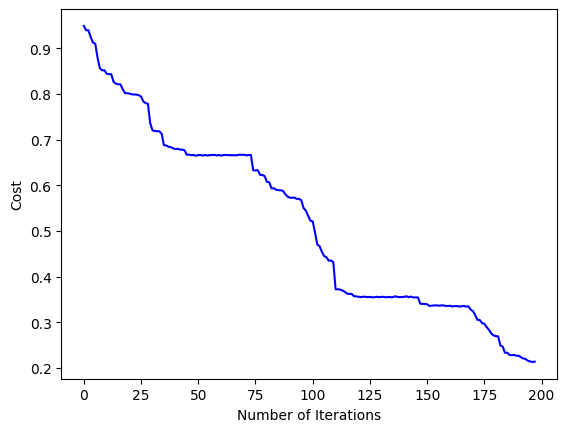

In [17]:
plt.plot(range(len(Cost)), Cost,'b')
# plt.axis([0, 100, 0, 0.0007])
plt.xlabel('Number of Iterations')
plt.ylabel('Cost')
plt.show()


In [18]:
x_exact = np.linalg.solve(m,b)
x_exact = x_exact/np.linalg.norm(x_exact)

In [19]:
e = []
F = []
norm_e = []
for k in range(len(Params)):
    state = np.array(Statevector(ansatz(Params[k])))
    psi = np.dot(m,state)
    Psi = psi/np.linalg.norm(psi)
    norm = np.dot(Psi,b)
    e.append(x_exact - state/norm)
    # f = abs(np.dot(Psi,b))**2
    f = abs(np.dot(state,x_exact))**2
    F.append(f)

for v in e:
    norm_e.append(float(np.linalg.norm(v)))

In [2]:
F = [0.03211711238571491, 0.03929686761667284, 0.04672126205307355, 0.04632319354989321, 0.05621490619814794, 0.05184164332791869, 0.055446315850118374, 0.08307793660875921, 0.09646114670850242, 0.09552303493472408, 0.11634471125345003, 0.12016759192381812, 0.12015102518552533, 0.12965244231515635, 0.12649145718045568, 0.1257718646466013, 0.12905021669262973, 0.14715504436662627, 0.15838999496925496, 0.15947800690555794, 0.15998734791079094, 0.16009502819031446, 0.1629600077400603, 0.16236531639192808, 0.16454646513984825, 0.15921302102669802, 0.18385855105388146, 0.18679279911232188, 0.18721204550984136, 0.22607280584496467, 0.21815132692722797, 0.21971989044693965, 0.21995470480303778, 0.21978198239936647, 0.21128662427208578, 0.23196443532295097, 0.2320144087475091, 0.23967435750322427, 0.23909445826819814, 0.24186469375845346, 0.2478510712037643, 0.2480476563166992, 0.248489732890177, 0.24802413181766816, 0.25283115159097524, 0.2541632129830819, 0.2553476428543856, 0.26298229730049855, 0.26298229730049855, 0.26298229730049855, 0.26298229730049855, 0.26298229730049855, 0.26298229730049855, 0.26298229730049855, 0.26298229730049855, 0.26298229730049855, 0.26298229730049855, 0.26298229730049855, 0.26298229730049855, 0.26298229730049855, 0.26298229730049855, 0.26298229730049855, 0.26298229730049855, 0.26298229730049855, 0.26298229730049855, 0.26298229730049855, 0.26298229730049855, 0.26298229730049855, 0.26298229730049855, 0.26298229730049855, 0.26298229730049855, 0.26298229730049855, 0.26517201272180674, 0.2623161443550492, 0.20845765393774762, 0.2082239314168563, 0.20817004507919268, 0.22131448994866532, 0.2214491048712561, 0.22235543540825498, 0.19785418542121339, 0.2049910292009534, 0.16655983303922706, 0.16748211358417794, 0.1675300110557088, 0.17104753491422597, 0.17091220269780696, 0.16997293366785265, 0.15193395706951215, 0.16315829253969819, 0.14625493612341267, 0.14614201883942865, 0.14586697923178726, 0.14845953664019998, 0.14824133409946422, 0.14350474577021335, 0.13262581711259416, 0.1634419334664893, 0.17876866749851006, 0.19528313284249668, 0.19474052656581484, 0.20725607025248244, 0.2710470926526158, 0.2694037893941784, 0.2692938593947404, 0.2667833899498743, 0.2700164533989794, 0.27398334906143973, 0.2740466629199275, 0.274897515695431, 0.2918030951920305, 0.292330018425175, 0.29349397133245486, 0.2822712087675463, 0.28355865046277945, 0.28392213550641077, 0.2805002019500706, 0.28078644838308076, 0.2898867238833734, 0.2992589939940325, 0.2992589939940325, 0.2992589939940325, 0.2992589939940325, 0.2992589939940325, 0.2992589939940325, 0.2992589939940325, 0.2992589939940325, 0.2992589939940325, 0.2992589939940325, 0.2992589939940325, 0.2992589939940325, 0.2992589939940325, 0.2992589939940325, 0.2992589939940325, 0.2992589939940325, 0.2992589939940325, 0.2992589939940325, 0.2992589939940325, 0.2992589939940325, 0.2992589939940325, 0.2992589939940325, 0.2992589939940325, 0.2992589939940325, 0.2992589939940325, 0.2951248284176357, 0.3103025479580143, 0.31019353487145535, 0.32109987223928627, 0.32210719472807314, 0.32390577966097883, 0.3233059301565169, 0.3154524629290624, 0.3172287627527384, 0.32652906860719955, 0.32674920097648946, 0.32689775770436147, 0.32724235495406323, 0.3276070771449559, 0.3285418264019054, 0.3262149925879127, 0.32631192734461995, 0.328993310814477, 0.3291631237153751, 0.3292264379631469, 0.32924688067204216, 0.3293814557110697, 0.32976782153374806, 0.3295481000160556, 0.3271122064546158, 0.3312973799707226, 0.3305428278815369, 0.32381396900190923, 0.32168200354483745, 0.32083383191834874, 0.3191023701110823, 0.3242060873014349, 0.3865727851250118, 0.3886737709947659, 0.39315571380007636, 0.38840176607485327, 0.3891688377526583, 0.38762433876573865, 0.3542414005702798, 0.5417865878305068, 0.5561146423225163, 0.5582342244544224, 0.56921400519497, 0.5693513839870576, 0.5705757604677143, 0.5702979259827445, 0.5727733072480221, 0.5783933794007561, 0.5823979931646306, 0.5830163309986925, 0.5825463915023783, 0.5806352387811671, 0.5828335415227625, 0.5829717119892452,0.5843761624732821, 0.5841515540265055, 0.5872784306505032, 0.5950114236135072, 0.5949781805439913, 0.6033778184292784, 0.6034957681608162, 0.6053262508755732, 0.605315135500309, 0.6053297785047775, 0.6055543426290998, 0.6048134730692273, 0.6046615533666466, 0.6047257333049675, 0.6048988470415837, 0.6048963637935546, 0.6048767203571118, 0.6049098697227947, 0.6050012994666428, 0.6048859154829135, 0.6048988231723909, 0.6048992895550721, 0.6049267774768898, 0.6049317031393245, 0.6048215975472552, 0.6062371291625691, 0.6033368339362385, 0.6030990884407622, 0.6059442244255498, 0.6095873532103964, 0.6120004275492227, 0.62917056822126, 0.6276069029331433, 0.629335478336457, 0.6277104698866227, 0.6282426332678308, 0.6283071973351507, 0.6290651644455456, 0.6291947036399061, 0.628387014559825, 0.632768774716113, 0.6323702660116215, 0.6322109504368523, 0.6313221623126873, 0.6313540075311244, 0.6286519560584242, 0.6271774161940386, 0.6414579621036922, 0.6414579621036922, 0.6414579621036922, 0.6414579621036922, 0.6414579621036922, 0.6414579621036922, 0.6414579621036922, 0.6414579621036922, 0.6414579621036922, 0.6414579621036922, 0.6414579621036922, 0.6414579621036922, 0.6414579621036922, 0.6414579621036922, 0.6414579621036922, 0.6414579621036922, 0.6414579621036922, 0.6414579621036922, 0.6414579621036922, 0.6414579621036922, 0.6414579621036922, 0.6414579621036922, 0.6414579621036922, 0.6414579621036922, 0.6414579621036922, 0.6426996316687642, 0.641741803008572, 0.6422868602810027, 0.642979765597039, 0.6429876209737732, 0.6437855138461622, 0.6438865054420787, 0.6439158136008701, 0.6439916959440034, 0.6442158735650904, 0.6434995734158301, 0.6434961031025416, 0.6434979393126147, 0.6435707968973297, 0.6435684632847231, 0.643606945999798, 0.643522688985124, 0.643554842979027, 0.6433242538447649, 0.6433328334729098, 0.6433232917837394, 0.6432991194518218, 0.6433008116498495, 0.6433642625369413, 0.6425761946009386, 0.6688264525275319, 0.6688067806508208, 0.6722207279397152, 0.6715364280106291, 0.6722212530142285, 0.6714065913018264, 0.6720006584213687, 0.6719618478062602, 0.6710038817808023, 0.6708561781117275, 0.6707929844817998, 0.6706599428936291, 0.671678601917814, 0.6711449078055338, 0.6705922589052152, 0.6707599764366444, 0.6704051918399234, 0.6705061817272683, 0.6707891435060417, 0.6686171765957531, 0.6683971770149045, 0.6685841658414408, 0.669203724463997, 0.669203724463997, 0.669203724463997, 0.669203724463997, 0.669203724463997, 0.669203724463997, 0.669203724463997, 0.669203724463997, 0.669203724463997, 0.669203724463997, 0.669203724463997, 0.669203724463997, 0.669203724463997, 0.669203724463997, 0.669203724463997, 0.669203724463997, 0.669203724463997, 0.669203724463997, 0.669203724463997, 0.669203724463997, 0.669203724463997, 0.669203724463997, 0.669203724463997, 0.669203724463997, 0.669203724463997, 0.670180652510203, 0.6715522730298563, 0.6715948239628071, 0.6724499280873372, 0.6725570806512504, 0.6725593645196883, 0.6702199300351859, 0.6665953016080752, 0.6670298439111717, 0.6700827530442895, 0.6700001943900611, 0.6699812151168583, 0.6695761882447301, 0.6695725106792291, 0.6703958229507725, 0.6694061770009997, 0.6693731573135819, 0.6693731573135819, 0.6693986421457838, 0.6694035738219837, 0.6693374876184045, 0.6693338165365755, 0.669492084471446, 0.6693168625954286, 0.6689982063483861, 0.6765948822010892, 0.6777944329332651, 0.6748239467921354, 0.673040118395305, 0.6723328643118448, 0.6697480744187138, 0.6728049480571786, 0.6992860550267235, 0.6999052674324717, 0.7005998798008141, 0.700398671552205, 0.7003681967650438, 0.6997962903960434, 0.6955162873241449, 0.7700288441085129, 0.7718955601992199, 0.7712240837930057, 0.7744545902508997, 0.7747317477416238, 0.7747499443839355,0.7767064332453077, 0.7766990800887571, 0.7766904846686324, 0.7791815894955103, 0.7787311480882941, 0.7811356528860594, 0.7821374644092095, 0.7825728518576197, 0.7825912258846249, 0.7825914789061733, 0.7825933066826598, 0.782473721679282, 0.7825063361310506, 0.7825148905185284, 0.7825186440843589, 0.7825280103086278, 0.7825184354633812, 0.7825190170455184, 0.7825223470931785, 0.7823893078803489, 0.7823280547374609, 0.782366558777881, 0.7823862985482763, 0.7823933972057434, 0.7817241779176222, 0.7816475885498979, 0.7807774378341985, 0.7819100860710448, 0.7822381534446676, 0.7828899395528751, 0.7824055018710503, 0.7834016382079994, 0.7822214794226495, 0.7826187029286942, 0.7821062156874699, 0.7821732427857446, 0.7821791724910964, 0.7820711841128065, 0.7821423970775667, 0.7821288012025551, 0.7826888595579415, 0.7826068350842766, 0.7824789451712743, 0.7824797729981108, 0.7823957112990103, 0.7821261692873468, 0.7820422135603669, 0.7824061616725954, 0.7824061616725954, 0.7824061616725954, 0.7824061616725954, 0.7824061616725954, 0.7824061616725954, 0.7824061616725954, 0.7824061616725954, 0.7824061616725954, 0.7824061616725954, 0.7824061616725954, 0.7824061616725954, 0.7824061616725954, 0.7824061616725954, 0.7824061616725954, 0.7824061616725954, 0.7824061616725954, 0.7824061616725954, 0.7824061616725954, 0.7824061616725954, 0.7824061616725954, 0.7824061616725954, 0.7824061616725954, 0.7824061616725954, 0.7824061616725954, 0.7829621485252733, 0.7829277503188524, 0.782936938031955, 0.7830095739810631, 0.7830391473379926, 0.7832635252661635, 0.7832586071553241, 0.7832691929101648, 0.7832308388472736, 0.7832651492022493, 0.783174502311873, 0.7831736867299067, 0.7831645796992213, 0.7831946619924385, 0.7832192103020472, 0.7832216846699585, 0.7833417404983071, 0.7833916444151625, 0.7833553321826245, 0.7833382516527387, 0.7833337038634446, 0.7833050595164099, 0.7833026774871531, 0.7832994131354457, 0.783169655905583, 0.7849478715345753, 0.7851974967988244, 0.7858582601959272, 0.7852775798035574, 0.7861725341498482, 0.7860020577801017, 0.7863353583575409, 0.7861877555078937, 0.7865037624446557, 0.7864718103402664, 0.7864311848686717, 0.7866334421000793, 0.7877195588675656, 0.7887161369033375, 0.7879812083881647, 0.7876543950324822, 0.7876119546450928, 0.7876219665851925, 0.7876712239873964, 0.7863841810445324, 0.7861898446987864, 0.7860210973262609, 0.7868002677991924, 0.7868002677991924, 0.7868002677991924, 0.7868002677991924, 0.7868002677991924, 0.7868002677991924, 0.7868002677991924, 0.7868002677991924, 0.7868002677991924, 0.7868002677991924, 0.7868002677991924, 0.7868002677991924, 0.7868002677991924, 0.7868002677991924, 0.7868002677991924, 0.7868002677991924, 0.7868002677991924, 0.7868002677991924, 0.7868002677991924, 0.7868002677991924, 0.7868002677991924, 0.7868002677991924, 0.7868002677991924, 0.7868002677991924, 0.7868002677991924, 0.7868537525194418, 0.7873829475385147, 0.7874068084349032, 0.7875621559531345, 0.7881336458105416, 0.7881449033048881, 0.7878785244934614, 0.7865203684587858, 0.7864242538844922, 0.7873393362152086, 0.7873264408618758, 0.7873128031341159, 0.7872129861526967, 0.787196192261573, 0.7873668590134419, 0.787070442523187, 0.7870855709270387, 0.7870979436253273, 0.7871000399269853, 0.7870889316202623, 0.7869905211955767, 0.7870041541164294, 0.7869912490803206, 0.7870644464710579, 0.7871337130356352, 0.7900253581968443, 0.7903546527292562, 0.7897729689763368, 0.7893510595343957, 0.788974160449195, 0.7882269280701633, 0.7896314008246705, 0.7920191497881052, 0.7922468858594155, 0.7923405160503368, 0.7930506216792824, 0.7931023876967943, 0.7931827885158745, 0.7924930090547859, 0.808180115464732, 0.808371693748954,0.8093716825766538, 0.8093714076712499, 0.809204692798469, 0.8101835400502821, 0.8098894984302725, 0.8115043594733071, 0.8122044870192835, 0.8122945733148936, 0.8123168385508787, 0.8123187285362061, 0.8123632218966742, 0.8123206386096793, 0.8123021096768693, 0.8123181252944245, 0.8123355164476702, 0.8123363120897035, 0.8123166422151366, 0.8123141093696714, 0.812287354017864, 0.8122961853309612, 0.8123085940946018, 0.8123115435268103, 0.8123152087138308, 0.8123102770374252, 0.8115557245354674, 0.8115014515525969, 0.8111215922633425, 0.8119642432828555, 0.8123772192962412, 0.812826738909727, 0.8123446177354001, 0.8127157121367815, 0.8120655344534571, 0.8122389850106891, 0.8119790648321438, 0.8119767776181698, 0.8119859879172695, 0.8119209287927122, 0.8120450018223242, 0.8120728931120441, 0.812461908106792, 0.8123926025582964, 0.8122277550332687, 0.8121119484427598, 0.8120637354832569, 0.8116897709082055, 0.8116197295667918, 0.8117605596603457, 0.8117605596603457, 0.8117605596603457, 0.8117605596603457, 0.8117605596603457, 0.8117605596603457, 0.8117605596603457, 0.8117605596603457, 0.8117605596603457, 0.8117605596603457, 0.8117605596603457, 0.8117605596603457, 0.8117605596603457, 0.8117605596603457, 0.8117605596603457, 0.8117605596603457, 0.8117605596603457, 0.8117605596603457, 0.8117605596603457, 0.8117605596603457, 0.8117605596603457, 0.8117605596603457, 0.8117605596603457, 0.8117605596603457, 0.8117605596603457, 0.8121906997679718, 0.8122793566199664, 0.8122155904872519, 0.8123108164055637, 0.8123295824885316, 0.8124358932027284, 0.8123678656907088, 0.8123692982735726, 0.8123731200976091, 0.8123758122160464, 0.8123175240500674, 0.8123221643080382, 0.8123132886720714, 0.8122965387613799, 0.8123128443200327, 0.8123013039807657, 0.8122387595067897, 0.8121917962192002, 0.812249466858117, 0.8122435497553735, 0.8122462271263301, 0.8122727280126443, 0.8122756543027603, 0.8122782026036198, 0.8122516958598303, 0.8134932040369635, 0.8136563239457997]


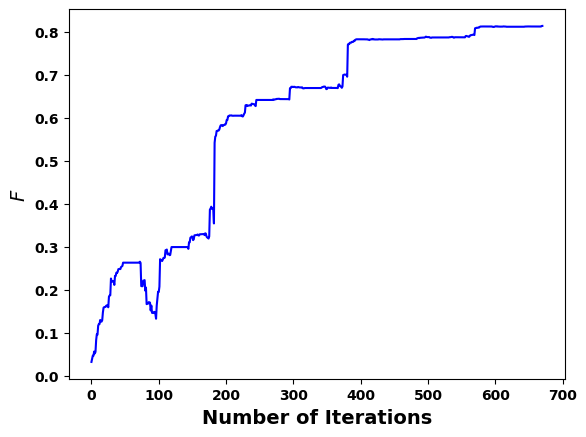

In [4]:
ax = plt.subplot(111)
ax.plot(range(len(F)), F, color = 'b')   

# plt.axis([0, 100, 0, 0.0007])
plt.xlabel('Number of Iterations',fontsize=14,weight='bold')
plt.ylabel('$F$',fontsize=14,weight='bold')
# plt.title('Cost Function for a full random matrix',fontsize=14,weight='bold')

ax = plt.gca()
for tick in ax.get_xticklabels():
	tick.set_fontweight('bold')
for tick in ax.get_yticklabels():
	tick.set_fontweight('bold')
# plt.savefig('cost_full_mat.eps')


In [25]:
print(norm_e)

[43.831460314996804, 26.078408060380553, 24.36074531157226, 7.851366668931858, 6.966053228408318, 6.004576020176787, 6.748229267009134, 6.1932557826870545, 6.705691582465671, 6.703858585814616, 6.605456067198393, 6.6995737880211355, 6.655262216484664, 8.043706296786999, 9.205068640481871, 9.060419350513415, 9.436516520102392, 8.278187681336473, 8.333662877068896, 8.409910594966226, 8.427028408129267, 8.924650709006087, 8.590252425891492, 8.39992971758067, 8.488075316828148, 6.767314283531048, 6.278299040262527, 6.66656408076659, 6.348170963745684, 6.27679173571982, 8.102341417183549, 8.101650521769722, 9.074437087457826, 9.04986400430118, 7.814685061508995, 7.0732833980450485, 7.17977788280655, 6.8367116204299245, 6.764006701466113, 7.216144803957748, 8.084548748455402, 8.067505978469441, 8.642728948074163, 8.642872407908802, 8.479900852831523, 10.05336365962152, 9.79657062194597, 9.085476118205783, 9.085476118205783, 9.085476118205783, 9.085476118205783, 9.085476118205783, 9.085476118

In [22]:
norm_e[np.argmax(F)]

17.649963028002333

Text(0.5, 0, 'Iteration')

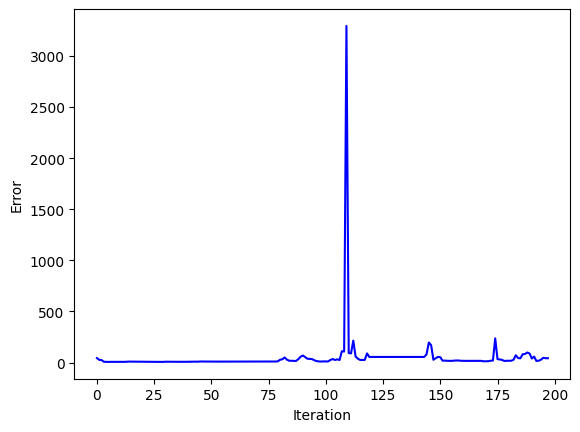

In [23]:
# plt.scatter(range(len(F)),F)
plt.plot(range(len(norm_e)),norm_e,'b')
# plt.axis([0, 100, 0, 0.0007])
plt.ylabel('Error')
plt.xlabel('Iteration')

In [24]:
Params[np.argmax(F)]

array([ 4.11102258e+00,  1.26109561e+00,  1.48038370e-01,  2.25272194e+00,
        1.65134738e+00,  5.79985077e-01, -5.92010792e-01, -4.05800549e-01,
        1.69930934e-01,  3.12408267e-01, -1.24781409e-01,  1.84344842e-01,
        9.73955977e-03, -2.87499767e-01, -3.15029500e-01,  2.86827889e-01,
        8.04574628e-01,  5.40688919e-01,  4.40473996e-01,  2.92917148e-01,
       -3.27028488e-03,  6.50009223e-01,  1.76991525e-01,  5.47255692e-01,
        6.66864872e-01,  5.32459616e-01, -1.55111044e-01,  1.62107738e-01,
        9.74378977e-01,  3.48497787e-02,  1.47148514e-01,  2.21830395e-01,
        6.87135352e-01,  2.65203152e-01,  5.89812828e-01,  9.06467170e-01,
        6.28375196e-01,  1.01261775e+00,  9.60896032e-01, -5.23356056e-02,
        5.25849584e-01,  8.84871061e-01,  8.35651916e-01,  8.66421774e-01,
        9.29180067e-01, -1.50784987e-01,  4.44657430e-01,  3.42719694e-01,
        3.20879430e+00, -3.87053080e-01,  1.92472720e-01,  6.66084923e-01,
        5.21082170e-01,  